<a href="https://colab.research.google.com/github/kimsh039/Eastar-Improved-punctuality/blob/main/eastar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl scikit-learn imbalanced-learn torch matplotlib

In [ ]:
!rm -rf runs

In [ ]:
from google.colab import files
import pandas as pd
import io
import re
from sklearn.preprocessing import LabelEncoder

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

X = df.iloc[:, [2,3,4,5]].copy()
y = df.iloc[:, 6].copy()

X.columns = ['이착륙횟수', '총비행시간', '월', '편명']


X['이착륙횟수'] = X['이착륙횟수'].astype(int)

def exact_time_to_minutes(time_val):
    import datetime
    if pd.isna(time_val):
        return 0

    if isinstance(time_val, (datetime.time, datetime.datetime)):
        return time_val.hour * 60 + time_val.minute
    if isinstance(time_val, pd.Timedelta):
        return int(time_val.total_seconds() // 60)

    time_str = str(time_val).strip()
    numbers = re.findall(r'\d+', time_str)

    if len(numbers) >= 2:
        return int(numbers[0]) * 60 + int(numbers[1])
    elif len(numbers) == 1:
        if '분' in time_str or 'm' in time_str:
            return int(numbers[0])
        else:
            return int(numbers[0]) * 60
    return 0

X['총비행시간'] = X['총비행시간'].apply(exact_time_to_minutes)

month_map = {
    'january': 1, 'febuary': 2, 'february': 2, 'march': 3, 'april': 4, 'may': 5, 'jun': 6, 'june': 6,
    'jul': 7, 'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12,
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

X['월'] = X['월'].astype(str).str.lower().str.strip().map(month_map).fillna(1)

le_flight = LabelEncoder()
X['편명'] = le_flight.fit_transform(X['편명'].astype(str).str.strip())

if y.dtype == 'object':
    y = y.map({'정상': 0, '지연': 1}).fillna(0)
else:
    y = pd.to_numeric(y, errors='coerce').fillna(0).astype(float)

X = X.astype(float)
y = y.astype(float)

print(X.head())
print(f"\n정비지연 정답(y) 개수 분포:\n{y.value_counts()}")

Saving flight_data.xlsx to flight_data (1).xlsx
   이착륙횟수  총비행시간    월     편명
0    2.0   54.0  1.0  165.0
1    4.0  118.0  1.0  166.0
2    6.0  257.0  1.0  110.0
3    8.0  374.0  1.0  111.0
4   10.0  459.0  1.0  112.0

정비지연 정답(y) 개수 분포:
ERROR
0.0    5437
1.0      43
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=2000, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"오버샘플링 후 훈련 데이터 클래스 분포:\n{pd.Series(y_train_resampled).value_counts()}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_resampled).unsqueeze(1)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

오버샘플링 후 훈련 데이터 클래스 분포:
ERROR
0.0    4350
1.0    4350
Name: count, dtype: int64


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 모델 아키텍처 정의
class MaintenanceClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MaintenanceClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MaintenanceClassifier(input_dim=4).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

train_losses = []
val_losses = []
val_accuracies = []

epochs = 300
patience = 20
best_val_loss = float('inf')
patience_counter = 0

print("학습 시작...")

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        val_X, val_y = X_val_tensor.to(device), y_val_tensor.to(device)
        val_outputs = model(val_X)
        average_val_loss = criterion(val_outputs, val_y).item()

        predictions = (val_outputs >= 0.5).float()
        correct = (predictions == val_y).sum().item()
        val_acc = correct / val_y.size(0)

    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {average_train_loss:.4f} | Val Loss: {average_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # 조기 종료
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"{epoch+1} 에폭에서 조기 종료")
        break

print("학습완료 'best_model.pth' 가중치가 저장")

학습 시작...
Epoch [1/300] | Train Loss: 0.6826 | Val Loss: 0.6421 | Val Acc: 0.5757
Epoch [5/300] | Train Loss: 0.6477 | Val Loss: 0.6313 | Val Acc: 0.5465
Epoch [10/300] | Train Loss: 0.6390 | Val Loss: 0.6408 | Val Acc: 0.5192
Epoch [15/300] | Train Loss: 0.6335 | Val Loss: 0.6509 | Val Acc: 0.5265
Epoch [20/300] | Train Loss: 0.6291 | Val Loss: 0.6577 | Val Acc: 0.5228
Epoch [25/300] | Train Loss: 0.6259 | Val Loss: 0.6432 | Val Acc: 0.5328
27 에폭에서 조기 종료
학습완료 'best_model.pth' 가중치가 저장


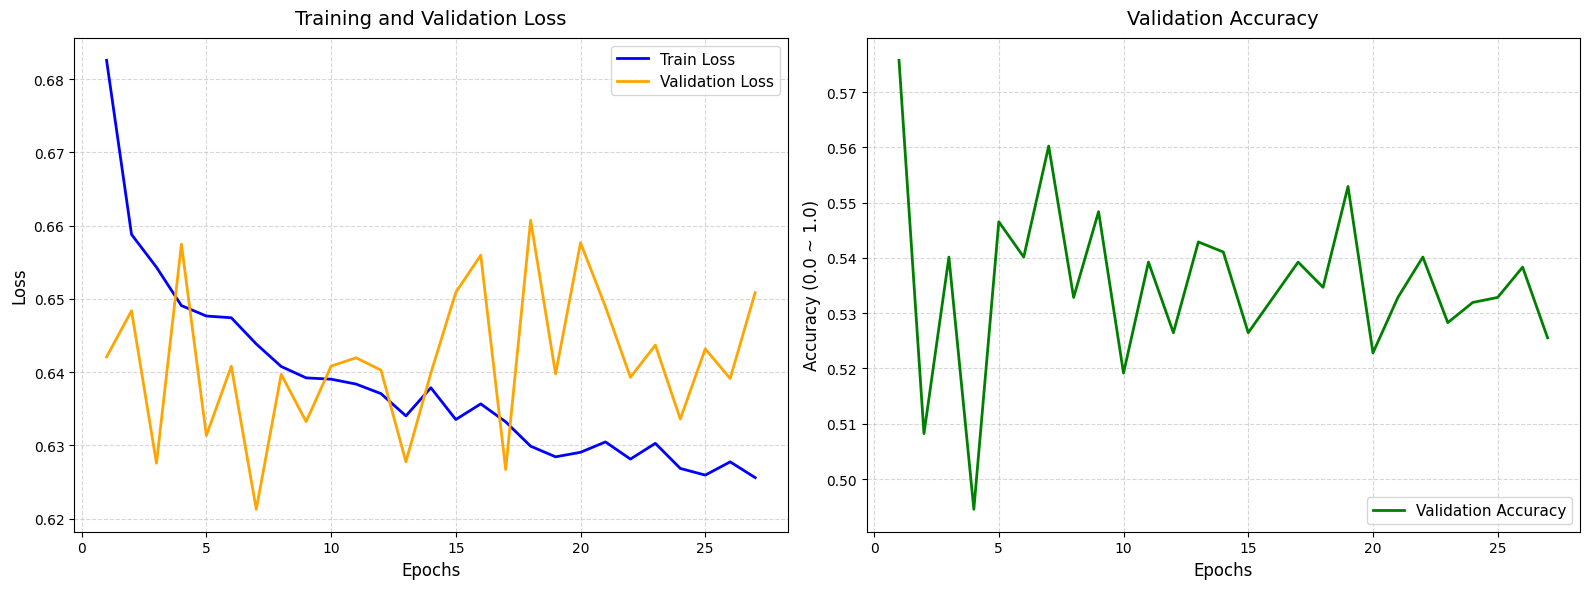

In [ ]:
import matplotlib.pyplot as plt

if 'train_losses' not in locals() or len(train_losses) == 0:
    print("메모리에 학습 로그가 없음")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    epochs_range = range(1, len(train_losses) + 1)

    ax1.plot(epochs_range, train_losses, label='Train Loss', color='blue', linewidth=2)
    ax1.plot(epochs_range, val_losses, label='Validation Loss', color='orange', linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14, pad=10)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green', linewidth=2)
    ax2.set_title('Validation Accuracy', fontsize=14, pad=10)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Accuracy (0.0 ~ 1.0)', fontsize=12)
    ax2.legend(fontsize=11, loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
with torch.no_grad():
    val_X = X_val_tensor.to(device)
    val_outputs = model(val_X)
    y_pred = (val_outputs >= 0.5).float().cpu().numpy()
    y_true = y_val_tensor.numpy()

cm = confusion_matrix(y_true, y_pred)
print("==== Confusion Matrix ====")
print(cm)
print("\n[해석]")
print(f"- 정상을 정상으로 맞춘 개수: {cm[0][0]}개")
print(f"- 정상을 지연으로 오인한 개수: {cm[0][1]}개")
print(f"- 지연을 정상으로 놓친 개수: {cm[1][0]}개")
print(f"- 지연을 지연으로 정확히 맞춘 개수: {cm[1][1]}개")

print("\n" + "="*50)
print("==== 종합 정밀도/재현율 리포트 ====")
print(classification_report(y_true, y_pred, target_names=['Normal(0)', 'Delay(1)']))

==== 📊 혼동 행렬 (Confusion Matrix) ====
[[569 518]
 [  2   7]]

[해석]
- 정상을 정상으로 맞춘 개수: 569개
- 정상을 지연으로 오인한 개수: 518개
- 지연을 정상으로 놓친 개수: 2개
- 지연을 지연으로 정확히 맞춘 개수: 7개

==== 🎯 종합 정밀도/재현율 리포트 ====
              precision    recall  f1-score   support

   Normal(0)       1.00      0.52      0.69      1087
    Delay(1)       0.01      0.78      0.03         9

    accuracy                           0.53      1096
   macro avg       0.50      0.65      0.36      1096
weighted avg       0.99      0.53      0.68      1096



In [ ]:
import torch
import numpy as np
import re

def predict_maintenance_delay(landing_count, flight_time_str, month_str, flight_number):
    """
    사용자가 입력한 임의의 값을 내부에서 완벽히 전처리하여 정비지연 확률을 예측합니다.
    """
    import datetime  # NameError 차단

    def local_time_convert(time_val):
        if pd.isna(time_val): return 0
        if isinstance(time_val, (datetime.time, datetime.datetime)):
            return time_val.hour * 60 + time_val.minute
        if isinstance(time_val, pd.Timedelta):
            return int(time_val.total_seconds() // 60)
        time_str = str(time_val).strip()
        numbers = re.findall(r'\d+', time_str)
        if len(numbers) >= 2: return int(numbers[0]) * 60 + int(numbers[1])
        elif len(numbers) == 1:
            return int(numbers[0]) if ('분' in time_str or 'm' in time_str) else int(numbers[0]) * 60
        return 0

    month_map = {
        'january': 1, 'febuary': 2, 'february': 2, 'march': 3, 'april': 4, 'may': 5, 'jun': 6, 'june': 6,
        'jul': 7, 'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12,
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
    }

    def local_month_convert(val):
        val_str = str(val).lower().strip()
        if val_str.isdigit(): return int(val_str)
        return month_map.get(val_str, 1)

    model.eval()
    with torch.no_grad():

        c1 = float(landing_count)
        c2 = float(local_time_convert(flight_time_str))
        c3 = float(local_month_convert(month_str))

        try:
            c4 = float(le_flight.transform([str(flight_number).strip()])[0])
        except (ValueError, NameError):
            c4 = 0.0

        raw_input = np.array([[c1, c2, c3, c4]])

        try:
            scaled_input = scaler.transform(raw_input)
        except NameError:
            print("오류: 전처리 스케일러(scaler) 객체가 메모리에 없음")
            return

        input_tensor = torch.FloatTensor(scaled_input).to(device)
        output = model(input_tensor)
        probability = output.item()

        print("\n" + "="*40)
        print("[AI 모델 분석 결과]")
        print("="*40)
        print(f"입력 데이터 -> 이착륙: {landing_count}회 | 비행시간: {flight_time_str} ({int(c2)}분) | 월: {month_str} | 편명: {flight_number}")
        print(f"정비지연 발생 가능성: {probability * 100:.2f}%")

        if probability >= 0.5:
            print("판정: [정비지연 위험 수치 발생] 사전 예방 정비를 강력히 권고합니다.")
        else:
            print("판정: [정상 비행 가능] 특이 징후가 발견되지 않았습니다.")
        print("="*40)

test_landing = input("총 이착륙 횟수를 입력해주세요 :")
test_flight_time = input("총 비행시간을 입력해주세요 :")
test_month = input("몇월에 이륙 예정인지 입력해주세요 :")
test_flight_no = input("편명을 입력해주세요 :")

predict_maintenance_delay(
    landing_count=test_landing,
    flight_time_str=test_flight_time,
    month_str=test_month,
    flight_number=test_flight_no
)

총 이착륙 횟수를 입력해주세요 :1528
총 비행시간을 입력해주세요 :1442시간 41분
몇월에 이륙 예정인지 입력해주세요 :may
편명을 입력해주세요 :ze011

[AI 모델 분석 결과]
입력 데이터 -> 이착륙: 1528회 | 비행시간: 1442시간 41분 (86561분) | 월: may | 편명: ze011
정비지연 발생 가능성: 54.82%
판정: [정비지연 위험 수치 발생] 사전 예방 정비를 강력히 권고합니다.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
